In [5]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.io
from scipy import signal
import pywt
import time
from statsmodels.tsa.ar_model import AutoReg
from sklearn.linear_model import LogisticRegression
from sklearn import tree
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from statsmodels.tsa.ar_model import AutoReg
import pywt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import confusion_matrix, zero_one_loss
from sklearn.model_selection import train_test_split
import pandas as pd
from pathlib import Path
import sys

In [7]:
dossier_actuel = Path(__file__).resolve().parent if "__file__" in locals() else Path.cwd()
racine_projet = dossier_actuel.parent
sys.path.append(str(racine_projet))
%load_ext autoreload
%autoreload 2
import scripts.functions as fc

In [55]:
def burg_algorithm(x, order):
    """
    Implémentation native de l'algorithme de Burg pour l'estimation AR.
    Équivalent à l'arburg de MATLAB (renvoie uniquement les coefficients).
    """
    x = np.asarray(x, dtype=float)
    N = len(x)
    
    if order >= N:
        raise ValueError("L'ordre AR doit être inférieur à la taille du signal.")
        
    # Initialisation des erreurs de prédiction avant (f) et arrière (b)
    f = x[1:].copy()
    b = x[:-1].copy()
    
    # Énergie initiale
    den = np.sum(f**2) + np.sum(b**2)
    
    # Initialisation des coefficients
    a = np.zeros(order)
    # Tableau temporaire pour stocker les coefficients précédents lors de la mise à jour
    a_prev = np.zeros(order)
    
    for k in range(1, order + 1):
        # Numérateur du coefficient de réflexion (num)
        num = -2.0 * np.sum(f * b)
        
        # Coefficient de réflexion
        rc = num / den
        
        # Mise à jour des coefficients AR (Formule de Levinson-Durbin)
        a[k-1] = rc
        if k > 1:
            a[:k-1] = a_prev[:k-1] + rc * a_prev[:k-1][::-1]
            
        a_prev[:k] = a[:k]
        
        # Mise à jour des erreurs de prédiction pour l'étape suivante
        f_next = f[1:] + rc * b[1:]
        b_next = b[:-1] + rc * f[:-1]
        
        f = f_next
        b = b_next
        
        # Mise à jour du dénominateur pour l'étape suivante
        den = (1.0 - rc**2) * den - f[0]**2 - b[-1]**2
        
    return a

In [57]:
# ---------------------------
# Helper: equivalent buffer()
# ---------------------------


# ---------------------------
# Helper: equivalent buffer()
# ---------------------------
def buffer_signal(x, n):
    num_windows = len(x) // n
    return x[:num_windows * n].reshape(n, num_windows, order='F')


# ---------------------------
# blockAR
# ---------------------------
def blockAR(x, order, numbuffer):
    y = buffer_signal(x, numbuffer)
    num_windows = y.shape[1]

    arcfs = np.zeros((order, num_windows))

    for kk in range(num_windows):
        segment = y[:, kk]
        try:
            model = AutoReg(segment, lags=order, old_names=False).fit()
            coef = model.params[1:]  # remove intercept
        except:
            coef = np.zeros(order)

        arcfs[:, kk] = coef

    arcfs = arcfs.reshape(order * num_windows)
    return arcfs


# ---------------------------
# Shannon Entropy
# ---------------------------
def shannonEntropy(x, numbuffer, level):
    y = buffer_signal(x, numbuffer)
    num_windows = y.shape[1]

    se = np.zeros((2 ** level, num_windows))

    for kk in range(num_windows):
        coeffs = pywt.wavedec(y[:, kk], 'db2', level=level)

        # reconstruction into energy bands (approximation of modwpt)
        energies = np.array([np.sum(c**2) for c in coeffs])

        total_energy = np.sum(energies)
        Pij = energies / (total_energy + np.finfo(float).eps)

        entropy = -np.sum(Pij * np.log(Pij + np.finfo(float).eps))

        # replicate to match Matlab shape
        se[:, kk] = entropy

    se = se.reshape((2 ** level) * num_windows)
    return se


# ---------------------------
# leaders (approximation)
# ---------------------------
def leaders(x, numbuffer):
    y = buffer_signal(x, numbuffer)
    num_windows = y.shape[1]

    cp = np.zeros(num_windows)
    rh = np.zeros(num_windows)

    for kk in range(num_windows):
        coeffs = pywt.wavedec(y[:, kk], 'db2')

        h = np.concatenate(coeffs)

        cp[kk] = np.mean(np.abs(h))  # approximation of cptmp(2)
        rh[kk] = np.max(h) - np.min(h)

    return cp, rh


# ---------------------------
# modwtvar approximation
# ---------------------------
def modwtvar(x):
    coeffs = pywt.wavedec(x, 'db2')
    return np.array([np.var(c) for c in coeffs])


# ---------------------------
# Main function
# ---------------------------
def helperExtractFeatures(trainData, testData, T, AR_order, level):
    trainFeatures = []
    testFeatures = []

    # ----- TRAIN -----
    for idx in range(trainData.shape[0]):
        x = trainData[idx, :]
        x = signal.detrend(x, type='constant')

        arcoefs = blockAR(x, AR_order, T)
        se = shannonEntropy(x, T, level)
        cp, rh = leaders(x, T)
        wvar = modwtvar(x)

        features = np.concatenate([
            arcoefs,
            se,
            cp,
            rh,
            wvar
        ])

        trainFeatures.append(features)

    trainFeatures = np.array(trainFeatures)

    # ----- TEST -----
    for idx in range(testData.shape[0]):
        x = testData[idx, :]
        x = signal.detrend(x, type='constant')

        arcoefs = blockAR(x, AR_order, T)
        se = shannonEntropy(x, T, level)
        cp, rh = leaders(x, T)
        wvar = modwtvar(x)

        features = np.concatenate([
            arcoefs,
            se,
            cp,
            rh,
            wvar
        ])

        testFeatures.append(features)

    testFeatures = np.array(testFeatures)

    # ---------------------------
    # Feature indices
    # ---------------------------
    featureindices = {}

    featureindices["ARfeatures"] = np.arange(0, 32)

    startidx = 32
    endidx = startidx + (16 * 8)
    featureindices["SEfeatures"] = np.arange(startidx, endidx)

    startidx = endidx
    endidx = startidx + 8
    featureindices["CP2features"] = np.arange(startidx, endidx)

    startidx = endidx
    endidx = startidx + 8
    featureindices["HRfeatures"] = np.arange(startidx, endidx)

    startidx = endidx
    endidx = startidx + 14
    featureindices["WVARfeatures"] = np.arange(startidx, endidx)

    return trainFeatures, testFeatures, featureindices

In [73]:
timeWindow = 8192;
ARorder = 4;
MODWPTlevel = 4;
X,y,signaux=fc.Import_Data()
#X=signaux


X = np.asarray(X)
y = np.asarray(y).ravel()

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    y,
    train_size=0.8,
    random_state=42,
    stratify=y
)

print("Labels initiaux :", np.unique(y, return_counts=True))
print("Labels train :", np.unique(Y_train, return_counts=True))
print("Labels test :", np.unique(Y_test, return_counts=True))
print("Labels train + test :", np.unique(np.concatenate([Y_train, Y_test]), return_counts=True))

X_train,Y_train,X_test,Y_test=np.array(X_train),np.array(Y_train),np.array(X_test),np.array(Y_test)
trainFeatures,testFeatures,featureindices = helperExtractFeatures(X_train,X_test,timeWindow,ARorder,MODWPTlevel);

Labels initiaux : (array(['A', 'C', 'N'], dtype='<U1'), array([96, 30, 36], dtype=int64))
Labels train : (array(['A', 'C', 'N'], dtype='<U1'), array([76, 24, 29], dtype=int64))
Labels test : (array(['A', 'C', 'N'], dtype='<U1'), array([20,  6,  7], dtype=int64))
Labels train + test : (array(['A', 'C', 'N'], dtype='<U1'), array([96, 30, 36], dtype=int64))


In [85]:
train_labels, test_labels = Y_train, Y_test 
trainLabels,testLabels=train_labels,test_labels

Nombre de lignes caractéristiques : 162
Nombre de lignes étiquettes : 162
Groupes uniques à tracer : ['A' 'C' 'N']
Shape all_features : (162, 522)
Labels : (array(['A', 'C', 'N'], dtype='<U1'), array([96, 30, 36], dtype=int64))
HR index : 168
HR min/max : 0.15045640559027182 1.6031480720281908


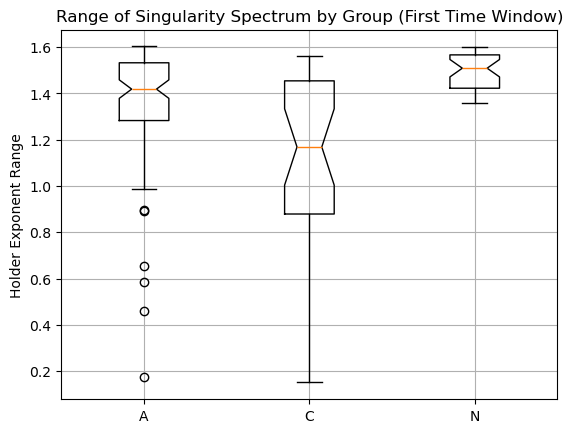

In [87]:
# 1. Concaténation verticale des caractéristiques et des étiquettes (labels)
# (En supposant que train_features, test_features, etc. soient des tableaux NumPy)
all_features = np.vstack([trainFeatures,testFeatures])
all_labels = np.concatenate([train_labels, test_labels])

print("Nombre de lignes caractéristiques :", all_features.shape[0])
print("Nombre de lignes étiquettes :", all_labels.shape[0])
print("Groupes uniques à tracer :", np.unique(all_labels)) # Doit afficher 3 groupes !
# 2. Extraction de la colonne correspondant aux caractéristiques HR
# Note importante : En Python, les indices commencent à 0. 
# Si feature_indices['HRfeatures'] est une liste d'indices (comme configurée précédemment),
# feature_indices['HRfeatures'][0] récupère le premier index de cette liste.
hr_first_index = featureindices['HRfeatures'][0]
data_to_plot = all_features[:, hr_first_index]




print("Shape all_features :", all_features.shape)
print("Labels :", np.unique(all_labels, return_counts=True))
print("HR index :", hr_first_index)
print("HR min/max :", np.min(data_to_plot), np.max(data_to_plot))


# 3. Création de la figure et du Boxplot
plt.figure()

# Pour grouper les données par "labels" comme le fait MATLAB automatiquement,
# nous devons séparer les données en listes distinctes pour chaque groupe unique.
unique_labels = np.unique(all_labels)
grouped_data = [data_to_plot[all_labels == label] for label in unique_labels]

# Création du boxplot avec l'encoche ('notch'=True)
plt.boxplot(grouped_data, labels=unique_labels, notch=True)

# 4. Habillage du graphique (Labels, Titre, Grille)
plt.ylabel('Holder Exponent Range')
plt.title('Range of Singularity Spectrum by Group (First Time Window)')
plt.grid(True)

# 5. Affichage du graphique
plt.show()

In [89]:
features = np.vstack([trainFeatures, testFeatures])
labels = np.concatenate([trainLabels, testLabels])

label_map = {
    "A": "ARR",
    "C": "CHF",
    "N": "NSR"
}

labels = np.array([label_map.get(label, label) for label in labels])

class_names = ["ARR", "CHF", "NSR"]

model = RandomForestClassifier()

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=1
)

classLabels = cross_val_predict(
    model,
    features,
    labels,
    cv=cv
)
print(classLabels)
loss = zero_one_loss(labels, classLabels) * 100

confmatCV = confusion_matrix(
    labels,
    classLabels,
    labels=class_names
)

print("Loss (%) =", loss)
print("Confusion matrix:")
print(confmatCV)

['ARR' 'NSR' 'ARR' 'ARR' 'NSR' 'ARR' 'ARR' 'ARR' 'ARR' 'ARR' 'ARR' 'CHF'
 'ARR' 'ARR' 'ARR' 'NSR' 'ARR' 'CHF' 'NSR' 'ARR' 'ARR' 'ARR' 'ARR' 'NSR'
 'ARR' 'CHF' 'ARR' 'ARR' 'ARR' 'NSR' 'ARR' 'NSR' 'ARR' 'ARR' 'NSR' 'ARR'
 'ARR' 'ARR' 'NSR' 'ARR' 'CHF' 'ARR' 'ARR' 'NSR' 'ARR' 'ARR' 'ARR' 'CHF'
 'ARR' 'ARR' 'CHF' 'ARR' 'ARR' 'CHF' 'ARR' 'ARR' 'CHF' 'ARR' 'CHF' 'ARR'
 'NSR' 'ARR' 'NSR' 'ARR' 'ARR' 'ARR' 'CHF' 'ARR' 'ARR' 'CHF' 'ARR' 'ARR'
 'NSR' 'NSR' 'CHF' 'CHF' 'ARR' 'ARR' 'ARR' 'ARR' 'ARR' 'CHF' 'CHF' 'NSR'
 'NSR' 'ARR' 'NSR' 'CHF' 'NSR' 'ARR' 'CHF' 'ARR' 'NSR' 'ARR' 'CHF' 'ARR'
 'ARR' 'CHF' 'ARR' 'NSR' 'ARR' 'NSR' 'ARR' 'NSR' 'ARR' 'NSR' 'ARR' 'ARR'
 'NSR' 'ARR' 'NSR' 'CHF' 'NSR' 'ARR' 'ARR' 'CHF' 'NSR' 'NSR' 'CHF' 'CHF'
 'NSR' 'ARR' 'ARR' 'ARR' 'CHF' 'ARR' 'NSR' 'NSR' 'ARR' 'NSR' 'ARR' 'CHF'
 'CHF' 'ARR' 'ARR' 'ARR' 'ARR' 'ARR' 'NSR' 'CHF' 'ARR' 'ARR' 'ARR' 'ARR'
 'ARR' 'NSR' 'ARR' 'CHF' 'ARR' 'ARR' 'ARR' 'ARR' 'NSR' 'CHF' 'ARR' 'NSR'
 'ARR' 'ARR' 'NSR' 'NSR' 'ARR' 'NSR']
Loss (%) = 6.

In [90]:


def helperPrecisionRecall(confmat):
    confmat = np.asarray(confmat, dtype=float)

    class_names = ["ARR", "CHF", "NSR"]

    precision = np.zeros(3)
    recall = np.zeros(3)
    f1_score = np.zeros(3)

    for i in range(3):
        # Precision = TP / total predicted as class i
        precision[i] = confmat[i, i] / np.sum(confmat[:, i]) * 100

        # Recall = TP / total true class i
        recall[i] = confmat[i, i] / np.sum(confmat[i, :]) * 100

        # F1-score
        f1_score[i] = (
            2 * precision[i] * recall[i] / (precision[i] + recall[i])
        )

    PRTable = pd.DataFrame(
        {
            "Precision": precision,
            "Recall": recall,
            "F1_Score": f1_score
        },
        index=class_names
    )

    return PRTable

In [93]:


PRTable = helperPrecisionRecall(confmatCV)
print(PRTable.round(3))


print(f"Cross-validation loss: {loss:.2f} %")
print(confmatCV)

     Precision  Recall  F1_Score
ARR     96.809  94.792    95.789
CHF     89.655  86.667    88.136
NSR     89.744  97.222    93.333
Cross-validation loss: 6.17 %
[[91  3  2]
 [ 2 26  2]
 [ 1  0 35]]
